# Transient & MCMC 

Let's study transient fenomena with the use of MCMC and Metropolis-Hastings algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [2]:
data = np.load("../Solutions/transient.npy")
time, flux, error = data.T

In [3]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL 

# Define the log-prior
def logPrior(theta):
    b, A, alpha, t0 = theta
    if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
        return -np.log(alpha) 
    return -np.inf 

# Define the log-posterior
def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

In [4]:
ndim = 4
nwalkers = 50

We need to take into account a thermalization time, plus the autocorralation. We run a smal test to set the burn and the thinning for the chain.

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_61305/3384519921.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 2000/2000 [00:01<00:00, 1472.02it/s]


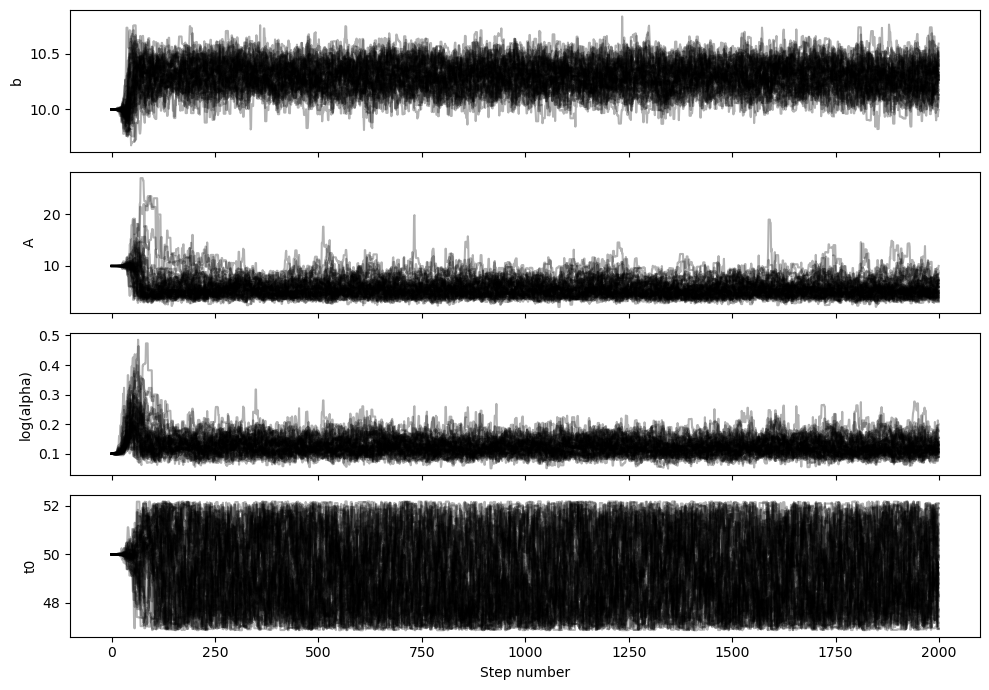

In [5]:
burn = 2000
try_sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sempler.run_mcmc(initial_pos, burn, progress=True)

traces = try_sempler.get_chain()
labels = ["b", "A", "log(alpha)", "t0"]
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(traces[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()

Let's conclude that we need at least 100 steps to burn the chain.

In [6]:
tau = try_sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [42.02285666 56.04625739 47.92071405 55.85215581]

In [7]:
# Run the sampler for a longer time to get better estimates, considering the autocorrelation time
burn = 500
nsteps = 10000

sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))

initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)

sempler.run_mcmc(initial_pos, nsteps, progress=True)

  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_61305/3384519921.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 10000/10000 [00:07<00:00, 1418.22it/s]


State([[10.260199    5.64243657  0.17701332 50.56937622]
 [10.4316346   5.01128276  0.13457357 49.72269503]
 [10.38939302  4.80957298  0.14379214 50.27634481]
 [10.33555968  3.44177591  0.08239039 50.37836759]
 [10.27091499  5.68093473  0.14789433 49.07042604]
 [10.2871167   6.40214445  0.11896574 47.64690253]
 [10.35851484  6.28923629  0.15351778 49.87492185]
 [10.43597267  2.96284316  0.08037859 50.99240674]
 [10.37964214  6.69608526  0.11141268 48.56865153]
 [10.26504772  4.55658845  0.12778957 51.10275496]
 [10.37712238  6.58890622  0.12214895 47.17503231]
 [10.34708244  4.27838925  0.09277975 47.38579436]
 [10.41557544  7.40914021  0.14232638 47.15714184]
 [10.38737294  4.27149748  0.12278111 51.59267466]
 [10.25827915  5.34640031  0.11613411 48.92790112]
 [10.44865304  4.2824195   0.13838609 50.46396154]
 [10.25472355  6.73079718  0.1740706  49.2289384 ]
 [10.35115048  7.0671136   0.12883781 47.30402107]
 [10.42872735  4.80968291  0.16552448 50.99344972]
 [10.53598629  5.53431016

In [8]:
tau = sempler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)

[52.36883671 71.88345806 60.33989492 71.28819204]


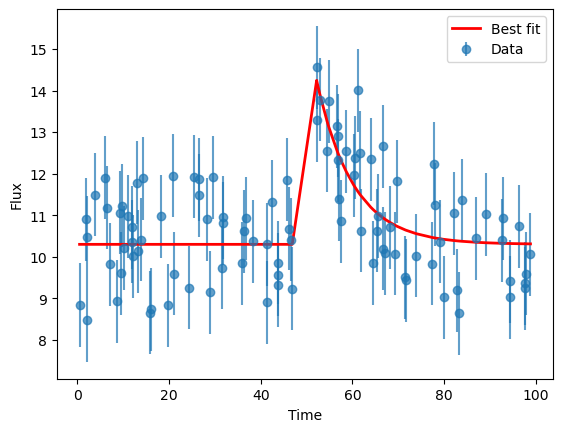

In [9]:
samples = sempler.get_chain(discard=burn, thin=thin, flat=True)

best_params = samples.mean(axis=0)

plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best fit', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

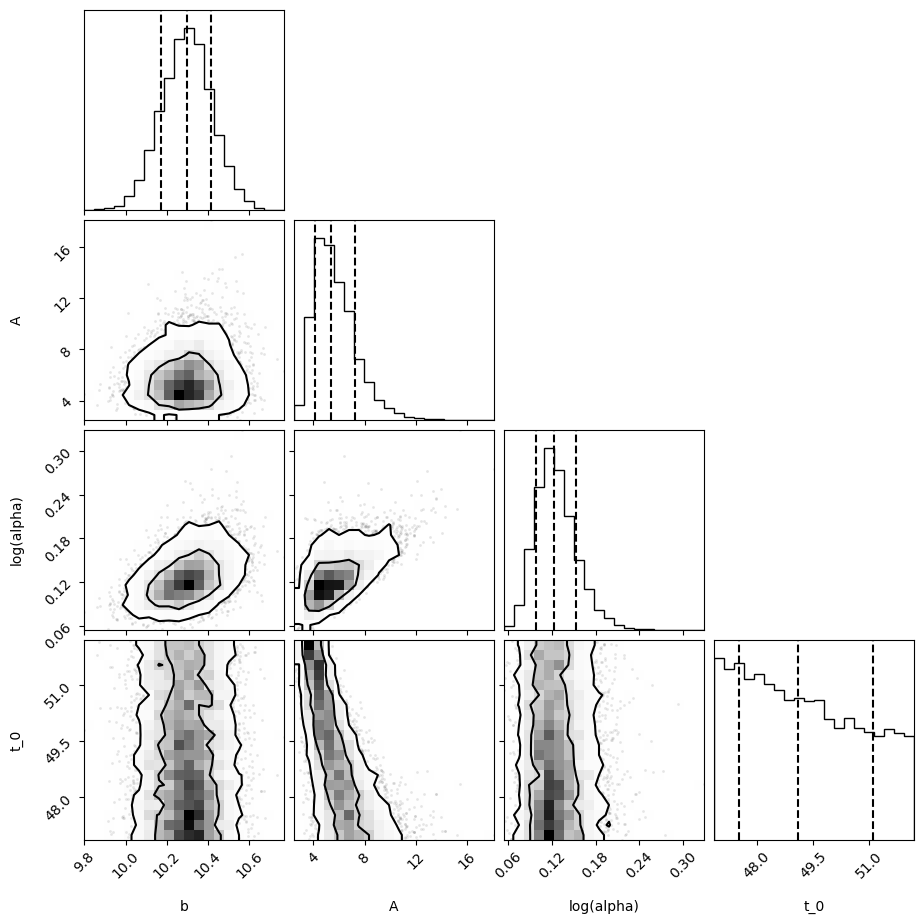

In [10]:
import corner as corner

labels = ["b", "A", "log(alpha)", "t_0"]

fig = corner.corner(
    samples, 
    labels=labels, 
    levels=[0.68, 0.95],
    quantiles=[0.16, 0.5, 0.84]
)
plt.show()

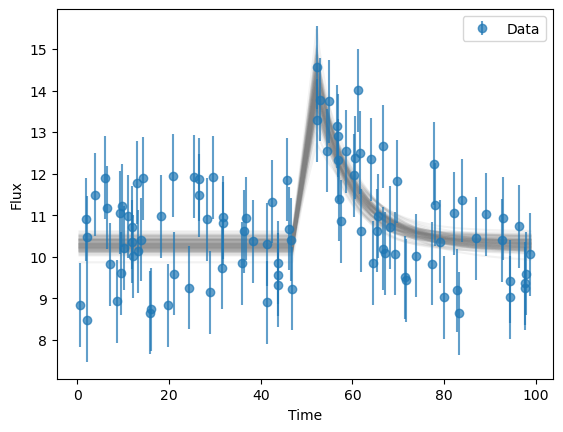

In [11]:
random_samples = samples[np.random.choice(samples.shape[0], size=100, replace=False)]

for i in range(len(random_samples)):
    y = Model(time, *random_samples[i])
    plt.plot(time, y, color='gray', alpha=0.1)
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()


In [12]:
median_params = np.median(samples, axis=0)
percentiles_params = np.percentile(samples, [5, 95], axis=0)

for i, param in enumerate(labels):
    print(f"{param}: {median_params[i]:.3f} (+{percentiles_params[1, i] - median_params[i]:.3f}, -{median_params[i] - percentiles_params[0, i]:.3f})")

b: 10.299 (+0.200, -0.204)
A: 5.411 (+3.449, -1.841)
log(alpha): 0.123 (+0.054, -0.037)
t_0: 49.111 (+2.723, -2.047)


We can also check the walker’s behavior.

Mean acceptance fraction: 0.532348
Acceptance fraction (per walker, first 10): [0.5315 0.5368 0.5365 0.5464 0.5308 0.5298 0.5397 0.5311 0.5413 0.5229]


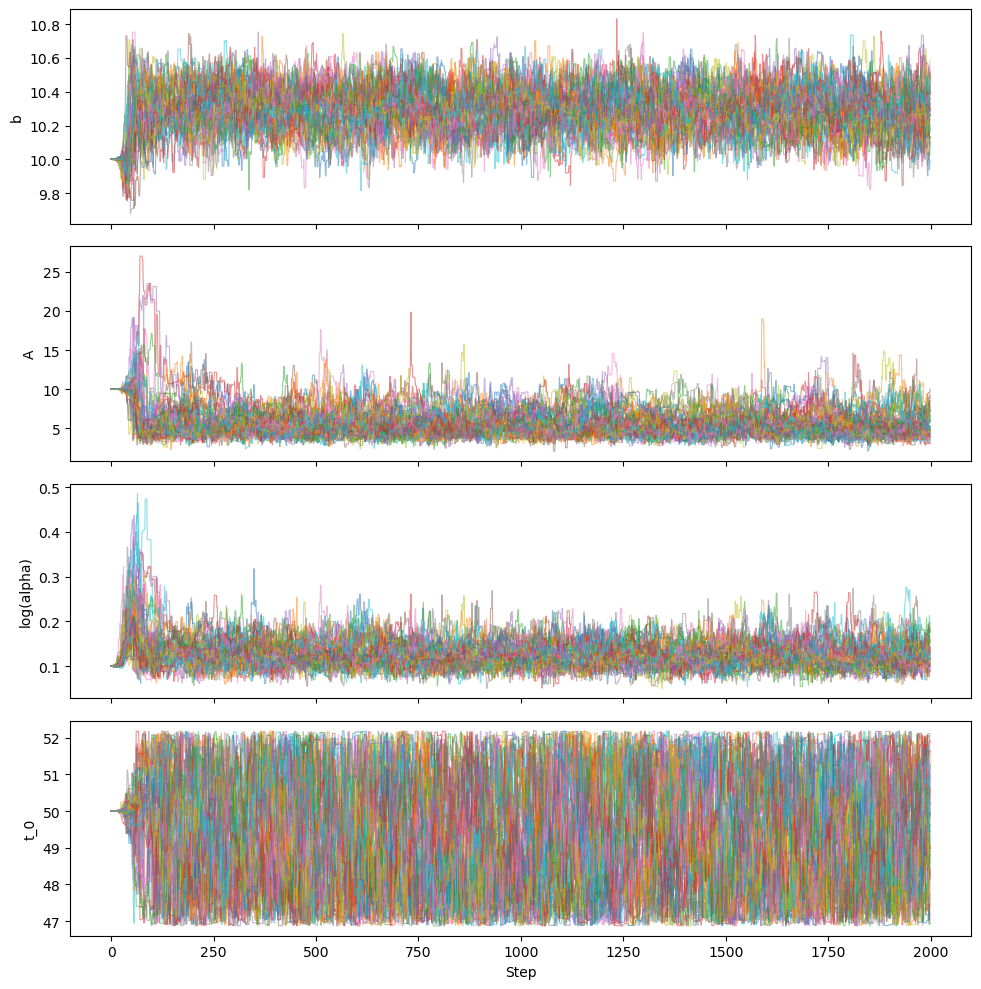

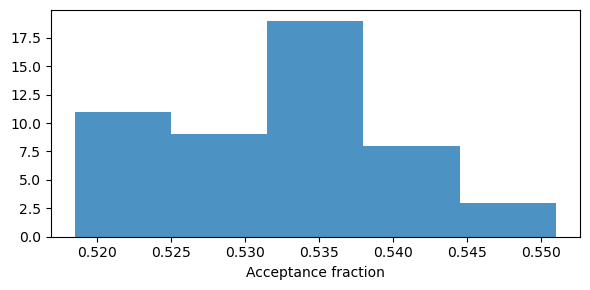

In [13]:
acc = getattr(sempler, "acceptance_fraction", None)
if acc is not None:
    print("Mean acceptance fraction:", acc.mean())
    print("Acceptance fraction (per walker, first 10):", acc[:10])

fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5 * ndim), sharex=True)
for j in range(ndim):
    ax = axes[j]
    ax.plot(traces[:, :, j], lw=0.8, alpha=0.5)
    ax.set_ylabel(labels[j])
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

if acc is not None:
    plt.figure(figsize=(6,3))
    plt.hist(acc, bins='scott', alpha=0.8)
    plt.xlabel("Acceptance fraction")
    plt.tight_layout()
    plt.show()

### Savage-Dickey ratio

Use to check that indeed we have a signal over noise.

In [15]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

def kde(samples, bandwith, kernel):
    kde = KernelDensity(bandwidth=bandwith, kernel=kernel)
    kde.fit(samples[:, None])
    return kde

In [18]:
gscv = GridSearchCV(KernelDensity(), {'bandwidth': np.logspace(-1, 1, 20)}, cv=5)
gscv.fit(samples[:, 1].reshape(-1, 1))
gscv.best_params_

{'bandwidth': 0.33598182862837817}

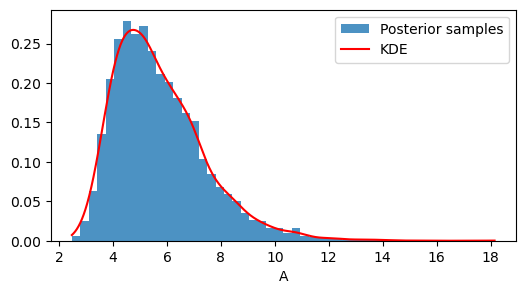

In [24]:
posterior_samples = samples[:, 1]
posterior_kde = kde(posterior_samples, bandwith=gscv.best_params_['bandwidth'], kernel='gaussian')

plt.figure(figsize=(6,3))
plt.hist(posterior_samples, bins='scott', density=True, alpha=0.8, label='Posterior samples')
x = np.linspace(posterior_samples.min(), posterior_samples.max(), 1000)[:, None]
log_dens = posterior_kde.score_samples(x)
plt.plot(x, np.exp(log_dens), 'r-', label='KDE')
plt.xlabel("A")
plt.legend()

In [25]:
A_ref = 0.0
posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
prior_density = 1 / 50
bayes_factor = prior_density / posterior_density

print(f'Posterior density at A={A_ref}: {posterior_density:.3e}')
print(f'Prior density at A={A_ref}: {prior_density:.3e}')
print(f'Savage-Dickey Bayes factor: {bayes_factor:.3f}')

Posterior density at A=0.0: 4.500e-16
Prior density at A=0.0: 2.000e-02
Savage-Dickey Bayes factor: 44441903193494.188


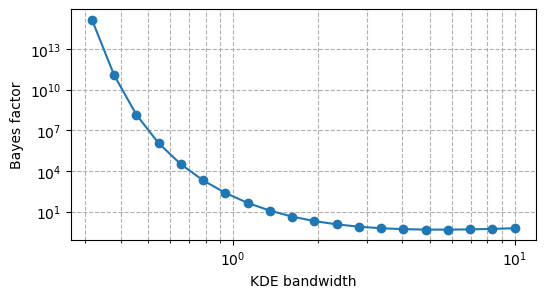

In [26]:
bandwith = np.logspace(-0.5, 1, 20)
bayesian_factors = []

for bw in bandwith:
    posterior_kde = kde(posterior_samples, bandwith=bw, kernel='gaussian')
    posterior_density = np.exp(posterior_kde.score_samples([[A_ref]]))[0]
    bayes_factor = prior_density / posterior_density
    bayesian_factors.append(bayes_factor)

plt.figure(figsize=(6,3))
plt.loglog(bandwith, bayesian_factors, marker='o')
plt.xlabel('KDE bandwidth')
plt.ylabel('Bayes factor')
plt.grid(True, which="both", ls="--")
plt.show()

We can confirm what we expected: we have identified a clear signal over noise. The last plot shows the importance of cross-validation for understanding the reliability of Bayes Factor, since it is sensitive to the KDE bandwidth choice in the tail region.